# AccuPrompt — Formulation Selector Simulation

This notebook explains and demonstrates the **machine-learning component** of
AccuPrompt: the algorithm that decides *which* of the four accuracy-prompt
formulations to show a user.

It is written to be read top-to-bottom: each section first **explains** a piece of
the idea or the code, then **runs** it. By the end you should understand exactly
what the algorithm does, see it learning, and understand the limits of what the
demonstration claims.

---

## 1. The problem: which formulation should we show?

AccuPrompt has **four** accuracy-prompt formulations (from Epstein et al., 2021):
*evaluation*, *importance*, *tips*, and *normative*. They are likely to differ in
how well they prompt a user to stop and reconsider before sharing — but we don't
know in advance which works best for a given audience, and the validation studies
were run on other populations.

This is a classic **exploration vs. exploitation** problem:

- **Exploit:** keep showing the formulation that has done best so far.
- **Explore:** keep trying the others, in case one is actually better and we just
  haven't shown it enough yet.

The standard, simplest algorithm for this is the **epsilon-greedy multi-armed
bandit**. "Multi-armed bandit" is an analogy to a row of slot machines ("one-armed
bandits"): each machine (here, each formulation) pays out at an unknown rate, and
you must learn which to play while not wasting too many pulls on bad ones. Each
formulation is an **arm**.

> This is exactly the algorithm implemented in the live extension
> (`src/content/selector.ts`). The Python in this notebook (`bandit.py`) is a
> faithful port of that same logic, so the simulation tests the **real policy**,
> not a different one.


## 2. What the algorithm does, in words

**Epsilon-greedy** uses a single tuning knob, **epsilon (ε)**, the probability of
exploring. With ε = 0.25:

1. **Cold start:** if any arm has never been shown, show one of those first
   (so every arm gets at least one trial — "optimistic initialisation").
2. **Explore (probability ε = 0.25):** pick an arm completely at random.
3. **Exploit (probability 1 − ε = 0.75):** pick the arm with the highest
   **mean reward** observed so far.

After each prompt we observe an **outcome** and convert it to a **reward**:

- the user **reconsiders or cancels** → reflective outcome → **reward = 1**
- the user **shares immediately** → **reward = 0**

Each arm tracks how many times it was shown and its total reward; its estimated
quality is simply `reward / shown`. Over many interactions the estimates get more
accurate and the algorithm spends more of its pulls on the best arm — while ε keeps
it from prematurely locking onto a lucky early winner.

Let's load the implementation and read the actual decision code.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from bandit import EpsilonGreedyBandit, UniformSelector, FORMULATIONS, EPSILON

print("Arms (formulations):", FORMULATIONS)
print("Exploration rate, epsilon:", EPSILON)


Arms (formulations): ['evaluation', 'importance', 'tips', 'normative']
Exploration rate, epsilon: 0.25


## 3. The key code: the selection rule

Below is the **exact** decision logic the extension uses. Read the three branches —
they map one-to-one onto the three rules in section 2 (cold-start, explore, exploit).


In [2]:
import inspect
print(inspect.getsource(EpsilonGreedyBandit.select))


    def select(self) -> str:
        # 1) try any never-shown arm first
        unseen = [f for f, a in self.arms.items() if a.shown == 0]
        if unseen:
            return self.rng.choice(unseen)
        # 2) explore
        if self.rng.random() < self.epsilon:
            return self.rng.choice(FORMULATIONS)
        # 3) exploit: best mean reward
        return max(FORMULATIONS, key=lambda f: self.arms[f].rate)



And the update rule — how an arm's tally changes after we see an outcome. `shown`
counts trials; `reward` accumulates the 1s; the arm's estimated rate is `reward/shown`
(see the `rate` property).


In [3]:
print(inspect.getsource(EpsilonGreedyBandit.update))
from bandit import Arm
print(inspect.getsource(Arm))


    def update(self, arm: str, reward: float) -> None:
        self.arms[arm].shown += 1
        self.arms[arm].reward += reward

@dataclass
class Arm:
    shown: int = 0
    reward: float = 0.0

    @property
    def rate(self) -> float:
        return self.reward / self.shown if self.shown > 0 else 0.0



For comparison, the **uniform** selector — used in the live extension *during*
walk-through sessions — does no learning at all: it deals the four formulations in a
shuffled round-robin so each gets equal exposure. We include it here as the baseline
the bandit must beat.


In [4]:
print(inspect.getsource(UniformSelector.select))


    def select(self) -> str:
        if not self.bag:
            self.bag = FORMULATIONS.copy()
            self.rng.shuffle(self.bag)
        return self.bag.pop()



## 4. The simulated environment

To watch the algorithm learn we need users to learn *from*. Since a real walk-through
produces only a handful of interactions (far too few to see a bandit converge), we
simulate many **synthetic users**. Each, when shown a formulation, reconsiders with a
fixed probability — the formulation's *true reflective rate*.

> **⚠ Honesty note — read this.** The rates below are **assumed, illustrative
> values chosen to make the demonstration legible.** They are **not** findings and
> make **no** claim that any formulation is actually better for real users. The
> simulation validates that the *algorithm* learns; the *real* rates would come from
> the cognitive walk-throughs or a deployed study.


In [5]:
# ASSUMED true reflective rates — ILLUSTRATIVE ONLY, not findings.
TRUE_RATES = {
    "evaluation": 0.55,   # assumed best
    "importance": 0.42,
    "tips":       0.48,
    "normative":  0.38,
}
BEST_ARM  = max(TRUE_RATES, key=TRUE_RATES.get)
BEST_RATE = TRUE_RATES[BEST_ARM]
print(f"Assumed best arm: {BEST_ARM} (rate {BEST_RATE})")


Assumed best arm: evaluation (rate 0.55)


## 5. The simulation loop, explained

The core loop does one thing per step: **ask the selector for an arm → simulate the
user's outcome → tell the selector the reward → record metrics.** Two metrics:

- **Cumulative regret** — at each step, the gap between the best arm's rate and the
  chosen arm's rate, summed over time. It measures *reward lost by not always picking
  the best arm.* A learner's regret should grow **slowly** (sub-linearly); a
  non-learner's grows in a straight line.
- **Selection share** — what fraction of picks each arm has received so far, tracked
  over time, so we can watch the bandit shift toward the best arm.

We run many independent repetitions and average, so the curves are smooth and
representative rather than one noisy run. Each function is commented below.


In [6]:
def simulate(make_selector, n_steps, seed):
    # One independent run of `n_steps` interactions with a fresh selector.
    rng_py = random.Random(seed)          # randomness for the selector's choices
    rng_np = np.random.default_rng(seed)  # randomness for the synthetic outcomes
    sel = make_selector(rng_py)
    cum_regret = np.zeros(n_steps)
    choices = []
    running = 0.0
    for t in range(n_steps):
        arm = sel.select()                                  # 1) algorithm picks an arm
        reward = 1.0 if rng_np.random() < TRUE_RATES[arm] else 0.0  # 2) user responds
        sel.update(arm, reward)                             # 3) algorithm learns
        running += (BEST_RATE - TRUE_RATES[arm])            # 4) regret for this pick
        cum_regret[t] = running
        choices.append(arm)
    return cum_regret, choices

def avg_runs(make_selector, n_steps, n_runs):
    # Average regret and selection-share across many independent runs.
    regrets = np.zeros((n_runs, n_steps))
    share = {f: np.zeros(n_steps) for f in FORMULATIONS}
    for r in range(n_runs):
        regret, choices = simulate(make_selector, n_steps, seed=1000 + r)
        regrets[r] = regret
        counts = {f: 0 for f in FORMULATIONS}
        for t, a in enumerate(choices):
            counts[a] += 1
            for f in FORMULATIONS:
                share[f][t] += counts[f] / (t + 1)   # cumulative share up to step t
    return regrets.mean(axis=0), {f: share[f] / n_runs for f in FORMULATIONS}

N_STEPS, N_RUNS = 600, 200
b_regret, b_share = avg_runs(lambda rng: EpsilonGreedyBandit(rng=rng), N_STEPS, N_RUNS)
u_regret, _       = avg_runs(lambda rng: UniformSelector(rng=rng), N_STEPS, N_RUNS)
print("Final cumulative regret  — bandit: %.1f | uniform: %.1f" % (b_regret[-1], u_regret[-1]))
print("Final selection share (bandit):",
      {f: round(float(b_share[f][-1]), 3) for f in FORMULATIONS})


Final cumulative regret  — bandit: 23.8 | uniform: 55.5
Final selection share (bandit): {'evaluation': 0.634, 'importance': 0.1, 'tips': 0.186, 'normative': 0.08}


## 6. Result 1 — Cumulative regret

If the bandit is learning, it should *lose less* over time than uniform selection.
Uniform never learns, so it keeps picking bad arms at the same rate forever — its
regret rises in a **straight line**. The bandit's regret should **bend and flatten**
as it figures out the best arm and stops wasting pulls.


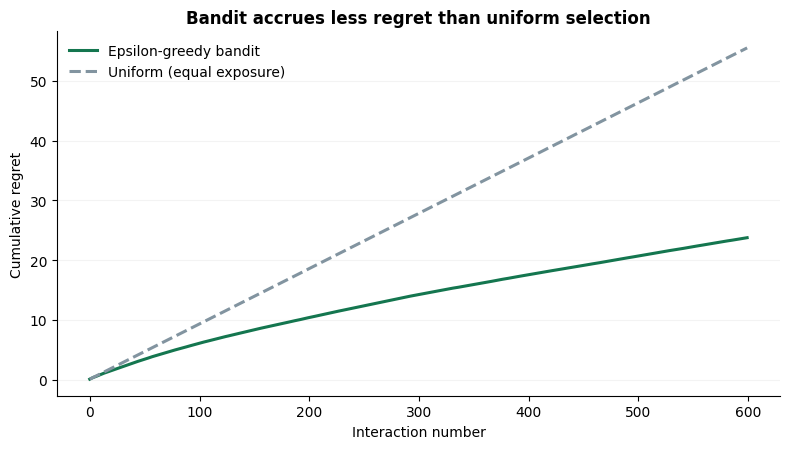

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(b_regret, color="#14764f", lw=2.2, label="Epsilon-greedy bandit")
ax.plot(u_regret, color="#8294a0", lw=2.2, ls="--", label="Uniform (equal exposure)")
ax.set_xlabel("Interaction number"); ax.set_ylabel("Cumulative regret")
ax.set_title("Bandit accrues less regret than uniform selection", fontweight="bold")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15); plt.tight_layout(); plt.show()


**Reading it:** the dashed grey line (uniform) is straight — no learning. The
green line (bandit) bends downward in slope — each extra interaction adds less regret,
because the bandit is increasingly picking the good arm. That gap *is* the learning.


## 7. Result 2 — Selection share over time

Here we watch *what the bandit chooses*. Early on, all four arms sit near 25% — that's
the exploration phase, where the algorithm is still gathering evidence. As estimates
firm up, the best arm's share climbs and the others fall (but never to zero — ε keeps
a trickle of exploration alive).


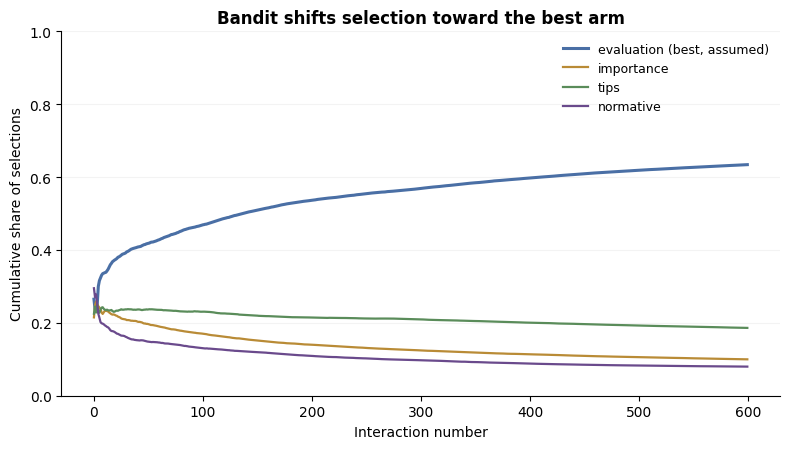

In [8]:
colors = ["#4A6FA5", "#B98B36", "#5A8C5A", "#6A4A8C"]
fig, ax = plt.subplots(figsize=(8, 4.6))
for i, f in enumerate(FORMULATIONS):
    lbl = f + (" (best, assumed)" if f == BEST_ARM else "")
    ax.plot(b_share[f], color=colors[i], lw=2.2 if f == BEST_ARM else 1.6, label=lbl)
ax.set_xlabel("Interaction number"); ax.set_ylabel("Cumulative share of selections")
ax.set_title("Bandit shifts selection toward the best arm", fontweight="bold")
ax.legend(frameon=False, fontsize=9); ax.set_ylim(0, 1)
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.15)
plt.tight_layout(); plt.show()


**Reading it:** all lines start bunched near 0.25 (equal). The *evaluation* arm
(the assumed-best one) separates upward; the weakest arms drift down. The fact that the
others don't collapse to zero is ε doing its job — the algorithm never fully stops
checking, so it could recover if the environment changed.


## 8. Result 3 — Did it learn the right numbers?

A final check: after many interactions, do the bandit's **estimated** reflective rates
(`reward/shown` per arm) actually approach the **assumed true** rates? If so, the
algorithm isn't just picking a winner by luck — it's correctly estimating the
environment.


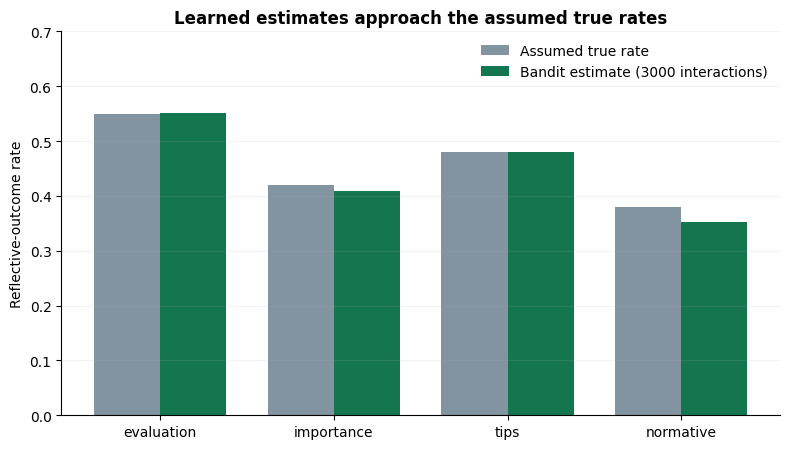

In [9]:
sel = EpsilonGreedyBandit(rng=random.Random(7))
rng_np = np.random.default_rng(7)
for _ in range(3000):                       # a single long run
    a = sel.select()
    sel.update(a, 1.0 if rng_np.random() < TRUE_RATES[a] else 0.0)

est  = [sel.arms[f].rate for f in FORMULATIONS]
true = [TRUE_RATES[f] for f in FORMULATIONS]
x = np.arange(len(FORMULATIONS)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.bar(x - w/2, true, w, label="Assumed true rate", color="#8294a0")
ax.bar(x + w/2, est,  w, label="Bandit estimate (3000 interactions)", color="#14764f")
ax.set_xticks(x); ax.set_xticklabels(FORMULATIONS)
ax.set_ylabel("Reflective-outcome rate")
ax.set_title("Learned estimates approach the assumed true rates", fontweight="bold")
ax.legend(frameon=False); ax.set_ylim(0, 0.7)
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.15)
plt.tight_layout(); plt.show()


**Reading it:** the green bars (what the bandit learned) sit close to the grey
bars (the truth we assumed). The best-arm estimate is the tightest, because the bandit
sampled it most — it knows most about the arm it cares most about. Arms it explores
less are estimated a little more loosely, which is the expected and correct behaviour.


## 9. Summary and honest limits

**What this notebook showed**

- The implemented **epsilon-greedy multi-armed bandit** learns: it concentrates
  selection on the higher-reflective-rate formulation, drives **sub-linear regret**
  (beating uniform selection), and recovers the environment's rates.
- The same policy runs in the **live extension** (`selector.ts`); this is a faithful
  port, so the demonstration reflects the real component.

**What it did not show, and important limits**

- The reflective rates are **assumed**, not measured. This validates the *algorithm*,
  not the formulations.
- During the **actual walk-through study** the extension runs in **uniform mode**
  (equal exposure) for a fair qualitative comparison; the adaptive behaviour here is
  for use **outside** the controlled study.
- This is a **simple, non-contextual** bandit on four arms with a proxy reward. The
  natural next step — a **contextual** bandit that personalises the choice by user
  and message context — is **future work**, not implemented here.
